# EJEMPLO DE EDA PARA TRABAJO FINAL DE REGRESIÓN
## DATASET : https://www.kaggle.com/datasets/thedrzee/melbourne-house-prices-dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thedrzee/melbourne-house-prices-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.26M/1.26M [00:00<00:00, 76.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/thedrzee/melbourne-house-prices-dataset/versions/1


In [3]:
!ls /root/.cache/kagglehub/datasets/thedrzee/melbourne-house-prices-dataset/versions/1

MELBOURNE_HOUSE_PRICES_LESS.csv.csv


In [4]:
PATH_CSV = path + '/MELBOURNE_HOUSE_PRICES_LESS.csv.csv'

In [5]:
df = pd.read_csv(PATH_CSV)
df

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Postcode,Regionname,Propertycount,Distance,CouncilArea
0,Abbotsford,49 Lithgow St,3,h,1490000.0,S,Jellis,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
1,Abbotsford,59A Turner St,3,h,1220000.0,S,Marshall,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
2,Abbotsford,119B Yarra St,3,h,1420000.0,S,Nelson,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
3,Aberfeldie,68 Vida St,3,h,1515000.0,S,Barry,1/04/2017,3040,Western Metropolitan,1543,7.5,Moonee Valley City Council
4,Airport West,92 Clydesdale Rd,2,h,670000.0,S,Nelson,1/04/2017,3042,Western Metropolitan,3464,10.4,Moonee Valley City Council
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63018,Roxburgh Park,3 Carr Pl,3,h,566000.0,S,Raine,31/03/2018,3064,Northern Metropolitan,5833,20.6,Hume City Council
63019,Roxburgh Park,9 Parker Ct,3,h,500000.0,S,Raine,31/03/2018,3064,Northern Metropolitan,5833,20.6,Hume City Council
63020,Roxburgh Park,5 Parkinson Wy,3,h,545000.0,S,Raine,31/03/2018,3064,Northern Metropolitan,5833,20.6,Hume City Council
63021,Thomastown,3/1 Travers St,3,u,NaN,PI,Barry,31/03/2018,3074,Northern Metropolitan,7955,15.3,Whittlesea City Council


# EDA

In [6]:
df.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,object
Postcode,int64
Regionname,object


In [7]:
df.dtypes.value_counts()

,count
object,8
int64,3
float64,2


# TRATAMIENTO DE NULOS

In [9]:
df.isnull().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,14590
Method,0
SellerG,0
Date,0
Postcode,0
Regionname,0


In [10]:
df.shape

(63023, 13)

In [11]:
df_cleaned = df.dropna()
df_cleaned.shape

(48433, 13)

In [12]:
df_housing_test = df[df['Price'].isnull()]
df_housing_test.shape

(14590, 13)

In [13]:
df_housing_test.to_csv('housing_test.csv',index=None)

In [14]:
df_cleaned = df_cleaned.drop(columns=['Suburb', 'Address', 'Type','Method','SellerG','Date','Postcode','Propertycount','CouncilArea'])
df_cleaned

,Rooms,Price,Regionname,Distance
0,3,1490000.0,Northern Metropolitan,3.0
1,3,1220000.0,Northern Metropolitan,3.0
2,3,1420000.0,Northern Metropolitan,3.0
3,3,1515000.0,Western Metropolitan,7.5
4,2,670000.0,Western Metropolitan,10.4
...,...,...,...,...
63016,2,347700.0,South-Eastern Metropolitan,38.0
63017,3,808000.0,Northern Metropolitan,8.4
63018,3,566000.0,Northern Metropolitan,20.6
63019,3,500000.0,Northern Metropolitan,20.6


In [15]:
df_cleaned.dtypes

,0
Rooms,int64
Price,float64
Regionname,object
Distance,float64


In [16]:
df_cleaned.describe()

,Rooms,Price,Distance
count,48433.000000,4.843300e+04,48433.000000
mean,3.071666,9.978982e+05,12.702761
std,0.944708,5.934989e+05,7.550030
min,1.000000,8.500000e+04,0.000000
25%,2.000000,6.200000e+05,7.000000
50%,3.000000,8.300000e+05,11.700000
75%,4.000000,1.220000e+06,16.700000
max,31.000000,1.120000e+07,55.800000


# ANALISIS DE VARIABLES

In [38]:
variable = 'Distance'
data = df_cleaned[variable]

In [39]:
mean_val = data.mean()
median_val = data.median()
mode_val = data.mode()[0]

print(f"📊 Medidas de tendencia central de {variable}")
print(f"Media (μ): {mean_val:.2f}")
print(f"Mediana: {median_val:.2f}")
print(f"Moda: {mode_val:.2f}")

📊 Medidas de tendencia central de Distance
Media (μ): 11.88
Mediana: 11.20
Moda: 10.50


In [40]:
variance_val = data.var()
std_val = data.std()
range_val = data.max() - data.min()
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
iqr = q3 - q1
print(f"\n📈 Medidas de dispersión de {variable}")
print(f"Varianza (σ²): {variance_val:.2f}")
print(f"Desviación estándar (σ): {std_val:.2f}")
print(f"Rango: {range_val:.2f}")
print(f"Rango intercuartílico (IQR): {iqr:.2f}")


📈 Medidas de dispersión de Distance
Varianza (σ²): 38.47
Desviación estándar (σ): 6.20
Rango: 29.90
Rango intercuartílico (IQR): 9.40


# Identificación de outliers con la regla del IQR

In [41]:
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = data[(data < limite_inferior) | (data > limite_superior)]

print(f"\n⚠️ Detección de Outliers (Regla del IQR) para {variable}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print(f"Número de outliers detectados: {len(outliers)}")


⚠️ Detección de Outliers (Regla del IQR) para Distance
Límite inferior: -7.40
Límite superior: 30.20
Número de outliers detectados: 0


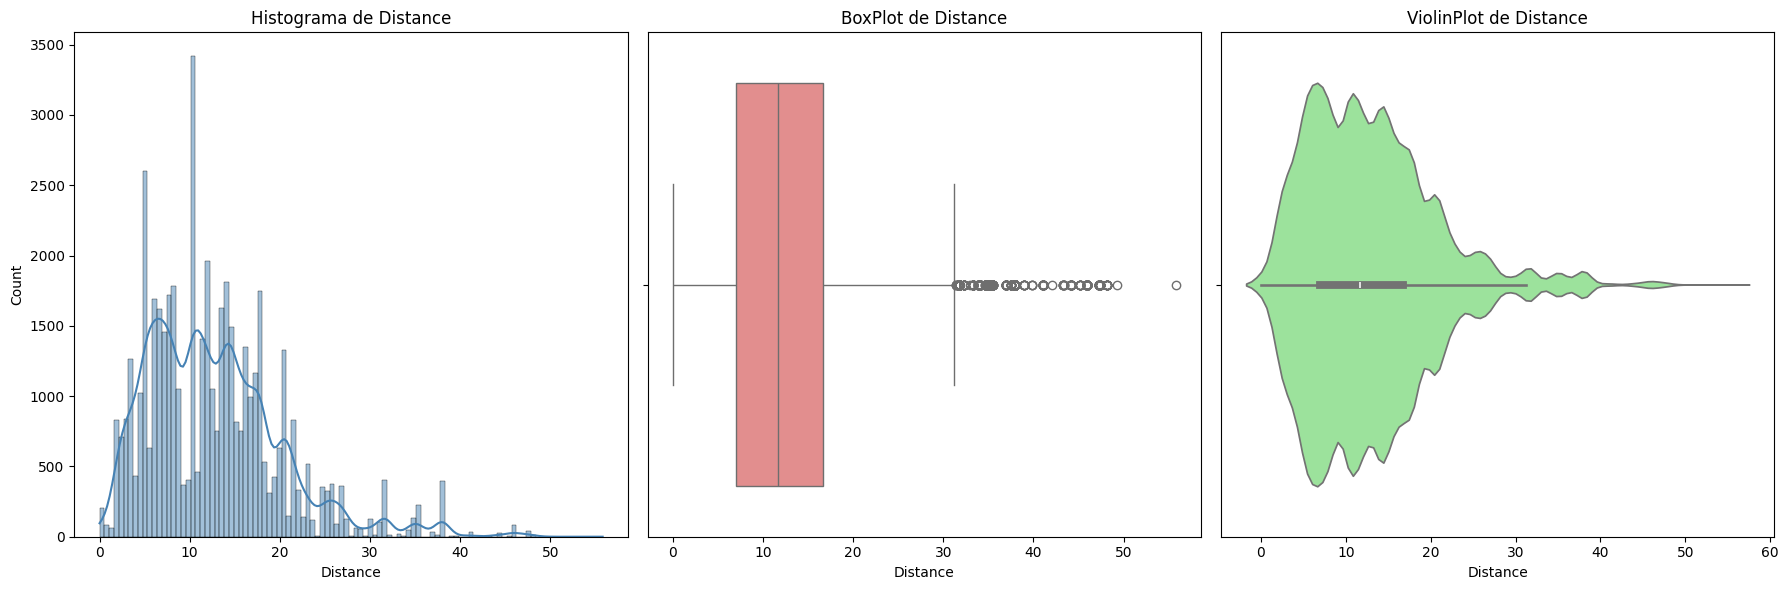

In [34]:
fig,axes = plt.subplots(1,3,figsize=(18,6))

#histograma
sns.histplot(data,kde=True,color='steelblue',ax=axes[0])
axes[0].set_title(f'Histograma de {variable}')

#boxplot
sns.boxplot(x=data,color='lightcoral',ax=axes[1])
axes[1].set_title(f'BoxPlot de {variable}')

#violinplot
sns.violinplot(x=data,color='lightgreen',ax=axes[2])
axes[2].set_title(f'ViolinPlot de {variable}')

plt.tight_layout()
plt.show()

# ELIMINAR OUTLIERS

In [35]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [37]:
df_cleaned = remove_outliers(df_cleaned,variable)
data = df_cleaned[variable]

In [29]:
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = data[(data < limite_inferior) | (data > limite_superior)]

print(f"\n⚠️ Detección de Outliers (Regla del IQR) para {variable}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print(f"Número de outliers detectados: {len(outliers)}")


⚠️ Detección de Outliers (Regla del IQR) para Rooms
Límite inferior: -1.00
Límite superior: 7.00
Número de outliers detectados: 0


In [42]:
df_cleaned

,Rooms,Price,Regionname,Distance
0,3,1490000.0,Northern Metropolitan,3.0
1,3,1220000.0,Northern Metropolitan,3.0
2,3,1420000.0,Northern Metropolitan,3.0
3,3,1515000.0,Western Metropolitan,7.5
4,2,670000.0,Western Metropolitan,10.4
...,...,...,...,...
63011,3,595000.0,South-Eastern Metropolitan,28.8
63017,3,808000.0,Northern Metropolitan,8.4
63018,3,566000.0,Northern Metropolitan,20.6
63019,3,500000.0,Northern Metropolitan,20.6


In [43]:
df_cleaned.to_csv('housing_clean.csv',index=None)